# Linear probe example

This notebook demonstrates a quick end-to-end CCDI-MCI workflow: (1) retrieve public clinical labels from CCDI cBioPortal, (2) join them to the released embedding manifest, (3) download a small balanced cohort from Hugging Face, and (4) fit a linear classifier on fixed TITAN slide embeddings.

The example predicts the cBioPortal sample-level **Cancer Type** attribute: **High-Grade Glioma** versus **Low-Grade Glioma**. It is intended as a usage example, but can be expanded as needed.

## Setup

`huggingface_hub`, `requests`, `pandas`, `numpy`, `h5py`, `scikit-learn`, and `matplotlib` are needed.

In [23]:
%pip install -q huggingface_hub requests pandas numpy h5py scikit-learn matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from huggingface_hub import hf_hub_download, snapshot_download
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, balanced_accuracy_score, f1_score, log_loss, roc_auc_score,
)
from sklearn.model_selection import train_test_split

DATA_DIR = Path("ccdi_mci_demo_data") # where embeddings will be downloaded to
N_PER_CLASS = None  # Set to None to use every matched patient.

LABEL_TO_ID = {"Low-Grade Glioma": 0, "High-Grade Glioma": 1}
CLASS_NAMES = list(LABEL_TO_ID)
print(CLASS_NAMES)

seed = 42
np.random.seed(seed)

['Low-Grade Glioma', 'High-Grade Glioma']


## Retrieve and join the clinical and imaging metadata

`CANCER_TYPE` is a sample-level clinical attribute in this study. The returned `patientId` joins to `patient_id` in the embedding release manifest. Other clinical attributes, including methylation class, are available from cBioPortal.

In [25]:
manifest_path = hf_hub_download(
    repo_id="CBIIT-CGBB/CCDI-MCI",
    repo_type="dataset",
    filename="metadata/slide_manifest.csv",
    local_dir=DATA_DIR,
)
manifest = pd.read_csv(manifest_path)

response = requests.get(
    "https://cbioportal-api.ccdi.cancer.gov/api/studies/phs002790/clinical-data",
    params={"clinicalDataType": "SAMPLE"},
    timeout=60,
)
response.raise_for_status()
clinical_records = response.json()

clinical = pd.DataFrame(
    {"patient_id": record["patientId"], "cancer_type": record["value"]}
    for record in clinical_records
    if record.get("clinicalAttributeId") == "CANCER_TYPE"
    and record.get("value") in CLASS_NAMES
).drop_duplicates()

clinical = clinical.drop_duplicates("patient_id")

eligible_slides = manifest.loc[
    manifest["has_titan"].fillna(False),
    ["patient_id", "series_instance_uid"],
].merge(clinical, on="patient_id", how="inner")

patients = (
    eligible_slides[["patient_id", "cancer_type"]]
    .drop_duplicates()
    .sort_values("patient_id")
    .reset_index(drop=True)
)

print(f"Matched patients: {patients['patient_id'].nunique():,}")
display(patients["cancer_type"].value_counts().rename("patients").to_frame())

Matched patients: 1,142


,patients
cancer_type,
Low-Grade Glioma,741
High-Grade Glioma,401


## Download all TITAN slide embeddings

+ Downloads the complete TITAN embedding set (approximately 660 MB).
+ Re-running this cell reuses files already present in `DATA_DIR`.

In [ ]:
print(f"Downloading all TITAN embeddings to {DATA_DIR}")

snapshot_download(
    repo_id="CBIIT-CGBB/CCDI-MCI",
    repo_type="dataset",
    allow_patterns="embeddings/titan/*/*.h5",
    local_dir=DATA_DIR,
    max_workers=16,
)

embedding_root = DATA_DIR / "embeddings" / "titan"
print(f"{len(list(embedding_root.glob('*/*.h5')))} TITAN HDF5 files")

Fetching 4570 files: 100%|██████████| 4570/4570 [05:04<00:00, 15.00it/s]  


Found 4,570 TITAN HDF5 files


## Select patients for the demo

+ Set `N_PER_CLASS` to an integer for a smaller balanced cohort or to `None` to use every matched patient.
+ Only the selected patients are loaded into memory for model fitting.

In [32]:
if N_PER_CLASS is None:
    cohort = patients.copy()
else:
    available = patients["cancer_type"].value_counts()
    too_small = available[available < N_PER_CLASS]
    if not too_small.empty:
        raise ValueError(f"Requested {N_PER_CLASS} patients per class, but found {too_small.to_dict()}")
    cohort = (
        patients.groupby("cancer_type", group_keys=False)
        .sample(n=N_PER_CLASS, random_state=seed)
        .sort_values("patient_id")
        .reset_index(drop=True)
    )

cohort["label"] = cohort["cancer_type"].map(LABEL_TO_ID).astype(int)
cohort_slides = eligible_slides.merge(cohort[["patient_id"]], on="patient_id")

patient_files = {
    patient_id: sorted((embedding_root / patient_id).glob("*.h5"))
    for patient_id in cohort["patient_id"]
}

missing = [patient_id for patient_id, paths in patient_files.items() if not paths]
if missing:
    raise FileNotFoundError(f"No downloaded embedding files for {len(missing)} patients: {missing[:5]}")

cohort["feature_paths"] = cohort["patient_id"].map(patient_files)
print(f"Selected {len(cohort):,} patients and {len(cohort_slides):,} slides")
display(cohort["cancer_type"].value_counts().rename("patients").to_frame())

Selected 1,142 patients and 1,178 slides


,patients
cancer_type,
Low-Grade Glioma,741
High-Grade Glioma,401


## Create patient-level splits and representations

+ Splitting happens at the patient level.
+ Each TITAN HDF5 file contains one 768-dimensional slide representation.
+ For patients with multiple slides, the slide vectors are averaged so each patient contributes one example.

In [33]:
train_df, remainder_df = train_test_split(
    cohort, test_size=0.30, stratify=cohort["label"], random_state=seed,
)
val_df, test_df = train_test_split(
    remainder_df, test_size=0.50, stratify=remainder_df["label"], random_state=seed,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

display(pd.DataFrame({
    "train": train_df.cancer_type.value_counts(),
    "validation": val_df.cancer_type.value_counts(),
    "test": test_df.cancer_type.value_counts(),
}).fillna(0).astype(int))

,train,validation,test
cancer_type,,,
Low-Grade Glioma,518,111,112
High-Grade Glioma,281,60,60


In [29]:
def load_patient_embedding(paths):
    slide_embeddings = []
    for path in paths:
        with h5py.File(path, "r") as handle:
            embedding = handle["features"][:].astype(np.float32).squeeze()
        if embedding.shape != (768,):
            raise ValueError(f"Expected a 768-element TITAN vector in {path}; got {embedding.shape}")
        slide_embeddings.append(embedding)
    return np.stack(slide_embeddings).mean(axis=0).astype(np.float32)

def load_split(split_df):
    features = np.stack([load_patient_embedding(paths) for paths in split_df["feature_paths"]])
    labels = split_df["label"].to_numpy()
    return features, labels

X_train, y_train = load_split(train_df)
X_val, y_val = load_split(val_df)
X_test, y_test = load_split(test_df)
print(f"Feature matrices: train {X_train.shape}, validation {X_val.shape}, test {X_test.shape}")

Feature matrices: train (799, 768), validation (171, 768), test (172, 768)


## Fit the linear probe

Regularization is selected by validation log loss. The final logistic-regression model is fit on the combined training and validation patients; the released TITAN embeddings remain fixed.

In [30]:
C_VALUES = [0.001, 0.01, 0.05, 0.1, 0.5, 1]
validation_records = []

for c_value in C_VALUES:
    candidate = LogisticRegression(
        C=c_value, solver="lbfgs", class_weight="balanced", max_iter=1_000, random_state=seed,
    )
    candidate.fit(X_train, y_train)
    validation_records.append({
        "C": c_value,
        "validation_log_loss": log_loss(
            y_val, candidate.predict_proba(X_val), labels=[0, 1]
        ),
    })

validation_results = pd.DataFrame(validation_records).sort_values(
    ["validation_log_loss", "C"]
).reset_index(drop=True)
best_c = float(validation_results.loc[0, "C"])
display(validation_results)
print(f"Selected C={best_c:g}")

model = LogisticRegression(
    C=best_c, solver="lbfgs", class_weight="balanced", max_iter=1_000, random_state=seed,
)
model.fit(
    np.concatenate([X_train, X_val]),
    np.concatenate([y_train, y_val]),
)

,C,validation_log_loss
0,0.010,0.275823
1,0.050,0.282664
2,0.100,0.296094
3,0.001,0.336758
4,0.500,0.369165
5,1.000,0.426640


Selected C=0.01


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Eval on the test patients

,linear-probe test metric
balanced_accuracy,0.934821
macro_f1,0.924858
roc_auc,0.980208


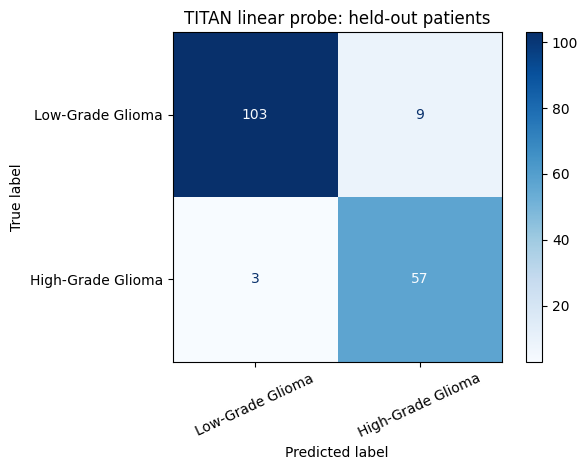

In [31]:
test_predictions = model.predict(X_test)
test_probabilities = model.predict_proba(X_test)[:, 1]
test_metrics = {
    "balanced_accuracy": balanced_accuracy_score(y_test, test_predictions),
    "macro_f1": f1_score(y_test, test_predictions, average="macro"),
    "roc_auc": roc_auc_score(y_test, test_probabilities),
}
display(pd.Series(test_metrics, name="linear-probe test metric").to_frame())

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=CLASS_NAMES,
    cmap="Blues",
    xticks_rotation=25,
)
plt.title("TITAN linear probe: held-out patients")
plt.tight_layout()
plt.show()

## Potential Additions

+ Increase `N_PER_CLASS` or set it to `None`.
+ Repeat patient-level splits across several seeds.
+ Try other clinical attributes by changing the attribute ID and label mapping.
> Other potential additions are discussed in our upcoming preprint.